# A constant-quality price index for England & Wales (hedonic-lite)

**Question.** How much of the 5.4× rise in the median sale price since 1995 is actual price growth, and how much is the *mix effect* (changes in what sold rather than what things cost)?

**Method.** OLS on the log of the sale price with dummies for year, property type, region, tenure and new-build status, fitted to a reproducible ~1.1M-row random sample (`sql/17_hedonic_sample_extract.sql`, seeded). The year coefficients trace the price of a *constant-quality* home - same type, same region, same tenure over time. Comparing that index to the raw median index isolates the mix effect.

**Honest scope.** This is *hedonic-lite*: Price Paid Data carries no floor area or room counts, so the model controls for the composition PPD can see, not full quality. The official UK HPI, with richer attributes, remains the benchmark. This notebook quantifies how far a median strays from a mix-adjusted view using this dataset alone. Upgrade path (EPC join for floor area) is Phase 7 in the README.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df = pd.read_csv('../data/processed/hedonic_sample.csv')
print(df.shape)
df.head()

/Users/qpingwin/miniconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/qpingwin/miniconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


(1173982, 6)


,price,year,type_name,tenure,is_new_build,region_name
0,690000,2019,Flat / Maisonette,L,0,London
1,100000,2019,Terraced,F,0,Yorkshire and The Humber
2,135000,2019,Terraced,F,0,West Midlands
3,482000,2019,Semi-detached,F,0,London
4,265995,2019,Detached,F,1,North East


## 1. Sanity checks
Before fitting anything: does the sample look like the market it was drawn from?

In [3]:
assert df['price'].gt(0).all(), 'non-positive prices'
assert df['year'].between(1995, 2025).all(), 'year out of range'
assert df['type_name'].nunique() == 4 and df['tenure'].isin(['F','L']).all()

print(df['year'].value_counts().sort_index().head(3))
print(df['type_name'].value_counts(normalize=True).round(3))
print(df['region_name'].value_counts(normalize=True).round(3))
print('new-build share:', df['is_new_build'].mean().round(3))

year
1995    31763
1996    38352
1997    43511
Name: count, dtype: int64
type_name
Terraced             0.299
Semi-detached        0.281
Detached             0.240
Flat / Maisonette    0.180
Name: proportion, dtype: float64
region_name
South East                  0.172
London                      0.126
North West                  0.121
East of England             0.115
South West                  0.110
Yorkshire and The Humber    0.091
West Midlands               0.089
East Midlands               0.085
Wales                       0.048
North East                  0.043
Name: proportion, dtype: float64
new-build share: 0.106


Shares match the full-data profile: terraced/semi most common, ~10% new-build, South East the largest region. Sampling check: 1995 has 31,763 rows vs a theoretical 4% × 793,286 = 31,731, uniform sampling is preserving each year's true market share.

## 2. The model

$\log(\text{price}_i) = \alpha + \sum_t \beta_t \, \text{year}_t + \sum_k \gamma_k \, \text{type}_k + \sum_r \delta_r \, \text{region}_r + \lambda \, \text{leasehold}_i + \mu \, \text{newbuild}_i + \varepsilon_i$

Log price, so coefficients read as percentage effects: $e^{\beta}-1$. Baselines: **1995** (year), **Terraced** (most common type), **South East** (largest region by volume), **Freehold** (tenure). Robust (HC1) standard errors - house prices are heteroskedastic by construction.

In [4]:
formula = ("np.log(price) ~ C(year, Treatment(1995)) "
           "+ C(type_name, Treatment('Terraced')) "
           "+ C(region_name, Treatment('South East')) "
           "+ C(tenure, Treatment('F')) + is_new_build")

model = smf.ols(formula, data=df).fit(cov_type='HC1')
print(f'n = {int(model.nobs):,}   R² = {model.rsquared:.3f}')

n = 1,173,982   R² = 0.679


## 3. Do the coefficients make sense?
Each premium below should match common knowledge about the housing market — if the detached premium came out negative, the pipeline would be broken somewhere.

In [5]:
def premium(name):
    return f"{(np.exp(model.params[name]) - 1) * 100:+.1f}%"

print('vs a terraced house (same year, region, tenure):')
print('  Detached      ', premium("C(type_name, Treatment('Terraced'))[T.Detached]"))
print('  Semi-detached ', premium("C(type_name, Treatment('Terraced'))[T.Semi-detached]"))
print('  Flat          ', premium("C(type_name, Treatment('Terraced'))[T.Flat / Maisonette]"))
print('vs the South East:')
print('  London        ', premium("C(region_name, Treatment('South East'))[T.London]"))
print('  North East    ', premium("C(region_name, Treatment('South East'))[T.North East]"))
print('other controls:')
print('  Leasehold     ', premium("C(tenure, Treatment('F'))[T.L]"))
print('  New build     ', premium('is_new_build'))

vs a terraced house (same year, region, tenure):
  Detached       +104.3%
  Semi-detached  +26.3%
  Flat           -2.0%
vs the South East:
  London         +66.9%
  North East     -51.8%
other controls:
  Leasehold      -11.7%
  New build      +20.3%


**R² = 0.679: five attributes explain two-thirds of the variance in log price across 1.17M sales.**

- **Detached +104%** - roughly double a terraced home, same year/region/tenure, consistent with the raw medians (£420k vs £240k), pushed up by regional controls since detached stock skews away from London.
- **Semi-detached +26%** - sits between terraced and detached, ordering preserved.
- **Flat -2.0%** - near zero *by construction*: the 'flats are cheaper' effect in raw data is mostly the leasehold discount, which the model books separately. Conditional on tenure, a flat ≈ a terraced house. The typical flat's total effect is ≈ -2.0% + (-11.7% leasehold) ≈ -13%. The regression has decomposed one raw gap into two causes.
- **London +66.9%, North East -51.8%** vs the South East - right signs, right magnitudes, bracketing the regional divergence in the README's finding #2.
- **Leasehold -11.7%** - negative as expected: a leasehold buyer gets a time-limited right to occupy, not the land itself, and inherits ground rent, service charges and eventual lease-extension costs. Identical homes should therefore sell at a discount when leasehold and they do.
- **New build +20.3%** - the well-documented new-build premium, independently consistent with query #7 which measures it directly.


## 4. The constant-quality index vs the median index
Exponentiating the year coefficients gives the price path of a standardised home (1995 = 100). The median index comes from the **full dataset** (the Tableau extract), not the sample so the comparison is sample-model vs population-median.

In [6]:
# constant-quality index from year coefficients
years = list(range(1995, 2026))
cq = [100.0]
for y in years[1:]:
    cq.append(100 * np.exp(model.params[f'C(year, Treatment(1995))[T.{y}]']))
cq_index = pd.Series(cq, index=years, name='constant_quality')

# median index from the full-population extract
ext = pd.read_csv('../tableau/extract_a_yearly_trends.csv')
nat = ext[(ext['region_rolled_up'] == 1) & (ext['type_rolled_up'] == 1)].set_index('year')
med_index = (100 * nat['nominal_median_price'] / nat.loc[1995, 'nominal_median_price']).rename('median')

idx = pd.concat([med_index, cq_index], axis=1)
idx.tail()

,median,constant_quality
2021,501.818182,503.041415
2022,527.272727,536.864057
2023,520.909091,536.450465
2024,527.272727,539.760333
2025,536.363636,552.473450


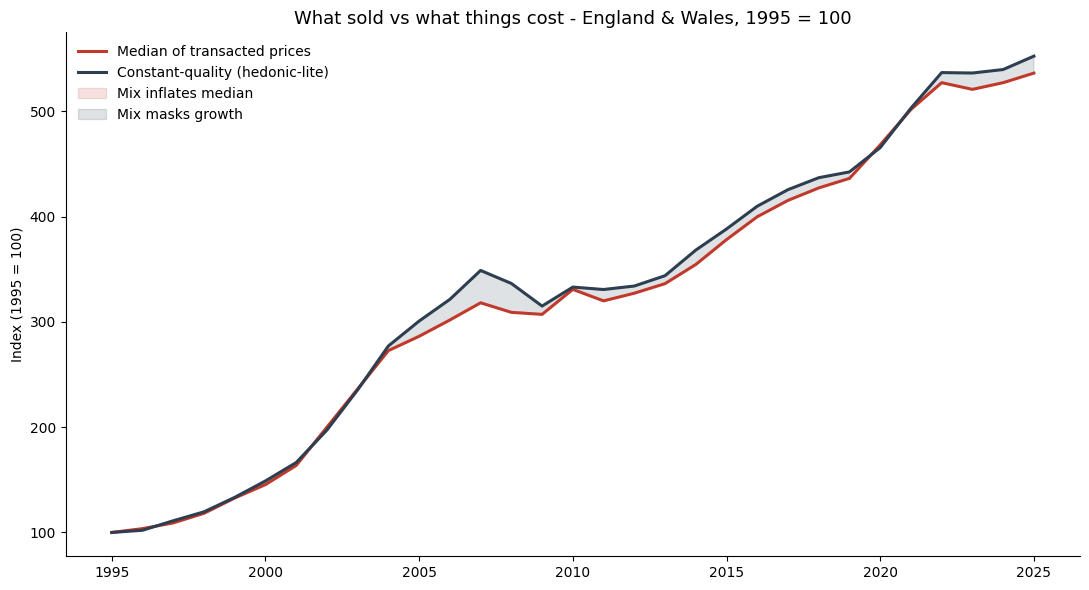

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(idx.index, idx['median'], lw=2.2, color='#c0392b', label='Median of transacted prices')
ax.plot(idx.index, idx['constant_quality'], lw=2.2, color='#2c3e50', label='Constant-quality (hedonic-lite)')
ax.fill_between(idx.index, idx['constant_quality'], idx['median'],
                where=idx['median'] >= idx['constant_quality'],
                alpha=0.15, color='#c0392b', label='Mix inflates median')
ax.fill_between(idx.index, idx['constant_quality'], idx['median'],
                where=idx['median'] < idx['constant_quality'],
                alpha=0.15, color='#2c3e50', label='Mix masks growth')
ax.set_title('What sold vs what things cost - England & Wales, 1995 = 100', fontsize=13)
ax.set_ylabel('Index (1995 = 100)')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../assets/hedonic_vs_median_index.png', dpi=150)
plt.show()

In [10]:
gap_2025 = idx.loc[2025, 'median'] - idx.loc[2025, 'constant_quality']
direction = 'overstates' if gap_2025 > 0 else 'understates'
print(f"2025: median index {idx.loc[2025,'median']:.0f}, constant-quality {idx.loc[2025,'constant_quality']:.0f}")
print(f"the median {direction} constant-quality growth by {abs(gap_2025):.0f} index points "
      f"({abs(gap_2025)/(idx.loc[2025,'constant_quality']-100)*100:.1f}% of true growth)")
print(f"multiples: median {idx.loc[2025,'median']/100:.2f}x vs constant-quality {idx.loc[2025,'constant_quality']/100:.2f}x")
print(f"\nyear-by-year gap (median - cq):")
print((idx['median'] - idx['constant_quality']).round(1).to_string())

2025: median index 536, constant-quality 552
the median understates constant-quality growth by 16 index points (3.6% of true growth)
multiples: median 5.36x vs constant-quality 5.52x

year-by-year gap (median - cq):
1995     0.0
1996     1.6
1997    -2.0
1998    -1.4
1999    -0.6
2000    -3.5
2001    -2.8
2002     2.7
2003     0.9
2004    -4.4
2005   -14.5
2006   -19.6
2007   -30.7
2008   -27.5
2009    -7.9
2010    -2.2
2011   -10.8
2012    -6.8
2013    -7.5
2014   -13.7
2015   -10.1
2016   -10.0
2017   -10.2
2018    -9.7
2019    -6.1
2020     2.6
2021    -1.2
2022    -9.6
2023   -15.5
2024   -12.5
2025   -16.1


## 5. Robustness (one honest check, not a ritual)
Refit on a random half of the sample. If the index moves materially, the sample is too small or something is unstable but if it barely moves, the estimates are solid.

In [11]:
half = df.sample(frac=0.5, random_state=7)
m2 = smf.ols(formula, data=half).fit()
cq2 = [100.0] + [100 * np.exp(m2.params[f'C(year, Treatment(1995))[T.{y}]']) for y in years[1:]]
max_dev = np.abs(np.array(cq2) - cq_index.values).max()
print(f'max index deviation on half-sample: {max_dev:.2f} points')

max index deviation on half-sample: 2.56 points


## 6. Limitations

- **No size controls** PPD has no floor area or room counts, so within-type quality drift (homes getting bigger/smaller) is invisible to this model. A true hedonic index (UK HPI) would control for it and the EPC join is the planned upgrade (Phase 7).
- **Tenure is coarse** PPD records that a property is leasehold but not the remaining lease length, which strongly affects price, meaning an 80-year lease is worth far less than a 999-year one. The leasehold dummy therefore captures the average discount across all lease lengths, not the term structure. (The HPI's input data shares this gap)
- **Constant coefficients** One pooled model assumes the detached premium, London premium etc. are constant across 30 years. Chained year-pair models would relax this.
- **Sample, not census** ~4% of eligible rows, the half-sample check above bounds the sampling error on the index.
- **Same exclusions as the rest of the project**: Category A sales only, type 'O' and postcode-less rows dropped.

## 7. Conclusion

A constant-quality home rose **5.52×** from 1995 to 2025, the median of transacted prices rose **5.36×**. The median *understates* true price growth by 16 index points (~3.6%) - the opposite of the expectation that mix effects inflate measured growth.

The gap is episodic, not constant, and each episode has a name:

- **1995–2004 and 2010–2019:** the two indices agree within a few points - at national, annual scale the median is an honest ruler in calm markets.
- **2007: −30.7 points**, the series' largest divergence, at the top of the pre-crash boom - city-centre flat-building flooded the sales mix with cheap stock, masking ~9% of true growth. The crash then narrowed the gap: credit dried up, first-time buyers vanished, and the mix snapped back toward richer homes.
- **2022–2025: reopening to −16.1**, driven by the new-build registration lag (premium stock missing from recent data - the +20.3% new-build coefficient quantifies what its absence costs the median) and prime London's shrinking share of transactions.

Robustness: refitting on a random half of the sample moves the index by at most **2.56 points** - the 16-point finding is ~6× larger than its sampling noise.

**Verdict:** the project's median-based headline figures survive quality adjustment - the 5.4× nominal multiple was, if anything, slightly conservative. But that claim could only be made after building the index that tests it.